<a href="https://colab.research.google.com/github/Piyush28062004/skin-disease/blob/main/archive1_skin_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOCK 1: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# COPY ZIP TO LOCAL SSD
# ============================================================

!cp /content/drive/MyDrive/archive1.zip /content/


In [ ]:
# ============================================================
# UNZIP DATASET LOCALLY
# ============================================================

!unzip -q /content/archive1.zip -d /content/

print("Dataset ready locally.")


Dataset ready locally.


In [ ]:
# ============================================================
# FIX FOLDER STRUCTURE
# ============================================================

import shutil
import os

ROOT = "/content/datasets"

src = os.path.join(ROOT, "PSORIASIS AND NORMAL SKIN")

# move NORMAL SKIN
shutil.move(
    os.path.join(src, "NORMAL SKIN"),
    os.path.join(ROOT, "NORMAL SKIN")
)

# move PSORIASIS
shutil.move(
    os.path.join(src, "PSORIASIS"),
    os.path.join(ROOT, "PSORIASIS")
)

# remove empty wrapper folder
shutil.rmtree(src)

print("Folder structure fixed.")


Folder structure fixed.


In [ ]:
# ============================================================
# BLOCK 2: DATASET PATH + CLASS DETECTION
# ============================================================

import os

# 🔴 CHANGE ONLY IF YOUR FOLDER NAME IS DIFFERENT
DATASET_PATH = "/content/datasets"

# Ensure dataset exists
assert os.path.exists(DATASET_PATH), "Dataset path not found. Check folder name."

# Detect class folders
class_names = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

NUM_CLASSES = len(class_names)

print("Detected Classes:\n")
for i, cls in enumerate(class_names):
    print(f"{i+1}. {cls}")

print("\nTotal Classes:", NUM_CLASSES)


Detected Classes:

1. NORMAL SKIN
2. PSORIASIS
3. dermatomyositis-images
4. morphea
5. pityrasis-alba-images
6. vitiligo

Total Classes: 6


In [ ]:
# ============================================================
# BLOCK 3: IMAGE COUNT PER CLASS
# ============================================================

import os
import pandas as pd

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for cls in class_names:

    class_path = os.path.join(DATASET_PATH, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(valid_ext)
    ]

    class_counts[cls] = len(images)

# Create table
count_df = pd.DataFrame.from_dict(
    class_counts,
    orient="index",
    columns=["Image_Count"]
).sort_values(by="Image_Count", ascending=False)

print("\nImages per class:\n")
print(count_df)

print("\nTotal images in dataset:", count_df["Image_Count"].sum())



Images per class:

                        Image_Count
PSORIASIS                     19272
vitiligo                      13248
dermatomyositis-images        10648
NORMAL SKIN                    4480
morphea                        3263
pityrasis-alba-images          1936

Total images in dataset: 52847


In [ ]:
# ============================================================
# BLOCK 3A — REMOVE CORRUPT IMAGES
# ============================================================

import tensorflow as tf

valid_ext = (".jpg",".jpeg",".png",".bmp",".webp")

bad_files = []

for cls in class_names:

    class_path = os.path.join(DATASET_PATH, cls)

    for f in os.listdir(class_path):
        if f.lower().endswith(valid_ext):

            path = os.path.join(class_path, f)

            try:
                img = tf.io.read_file(path)
                tf.image.decode_image(img)
            except:
                bad_files.append(path)

print("Corrupt images found:", len(bad_files))

for path in bad_files:
    os.remove(path)

print("Corrupt images removed.")


Corrupt images found: 0
Corrupt images removed.


Imbalance ratio (largest/smallest class): 9.95


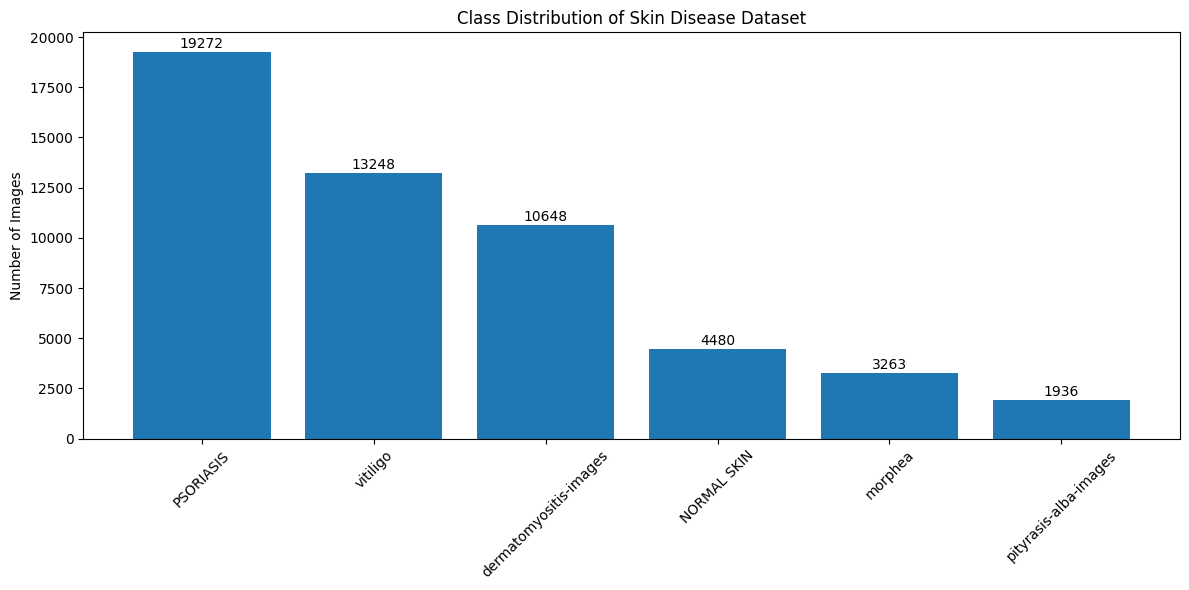

In [ ]:
# ============================================================
# BLOCK 4: CLASS IMBALANCE ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Extract values
classes = count_df.index.tolist()
counts = count_df["Image_Count"].values

# Calculate imbalance ratio
imbalance_ratio = max(counts) / min(counts)

print("Imbalance ratio (largest/smallest class):", round(imbalance_ratio, 2))

# Plot distribution
plt.figure(figsize=(12,6))
bars = plt.bar(classes, counts)

plt.title("Class Distribution of Skin Disease Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

# Annotate values
for i, v in enumerate(counts):
    plt.text(i, v + 200, str(v), ha='center')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# BLOCK 5: STRATIFIED TRAIN / VAL / TEST SPLIT (PATH-BASED)
# ============================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Step 1: Build dataframe of filepaths and labels
filepaths = []
labels = []

for label_index, cls in enumerate(class_names):

    class_path = os.path.join(DATASET_PATH, cls)

    for f in os.listdir(class_path):
        if f.lower().endswith(valid_ext):
            filepaths.append(os.path.join(class_path, f))
            labels.append(label_index)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total images collected:", len(df))


# Step 2: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# Step 3: Split temp into 15% val and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("\nDataset Split:")
print("Training set size:", len(train_df))
print("Validation set size:", len(val_df))
print("Test set size:", len(test_df))


Total images collected: 52847

Dataset Split:
Training set size: 36992
Validation set size: 7927
Test set size: 7928


In [ ]:
# ============================================================
# BLOCK 6: LOW-RAM IMAGE PIPELINE (FINAL)
# ============================================================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def build_dataset(dataframe, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["filepath"].values, dataframe["label"].values)
    )

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=2000)  # smaller buffer to save RAM

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = build_dataset(train_df, training=True)
val_ds   = build_dataset(val_df, training=False)
test_ds  = build_dataset(test_df, training=False)

print("Datasets rebuilt (low RAM mode).")


Datasets rebuilt (low RAM mode).


In [ ]:
# ============================================================
# BLOCK 7: DATA AUGMENTATION PIPELINE
# ============================================================

from tensorflow.keras import layers
import tensorflow as tf

# ---------- Augmentation model ----------
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1),

    layers.RandomBrightness(0.1)

])


# ---------- Apply augmentation only to training ----------
def augment(image, label):
    image = data_augmentation(image)
    return image, label


train_ds = train_ds.map(
    augment,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Augmentation pipeline applied to training dataset.")


Augmentation pipeline applied to training dataset.


In [ ]:
# ============================================================
# BLOCK 8: COMPUTE CLASS WEIGHTS
# ============================================================

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# labels from training dataframe
train_labels = train_df["label"].values

# compute weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class Weights:\n")

for i, w in class_weights.items():
    print(f"{class_names[i]} → {round(w,3)}")


Class Weights:

NORMAL SKIN → 1.966
PSORIASIS → 0.457
dermatomyositis-images → 0.827
morphea → 2.699
pityrasis-alba-images → 4.55
vitiligo → 0.665


In [ ]:
# ============================================================
# BLOCK 9: CNN MODEL ARCHITECTURE
# ============================================================

from tensorflow.keras import layers, models

NUM_CLASSES = len(class_names)

model = models.Sequential([

    # ----- Block 1 -----
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    # ----- Block 2 -----
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # ----- Block 3 -----
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # ----- Flatten -----
    layers.Flatten(),

    # ----- Dense Layer -----
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    # ----- Output Layer -----
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# BLOCK 10: COMPILE MODEL + TRAINING SETUP
# ============================================================

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ----- Compile -----
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----- Callbacks -----
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_skin_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

print("Model compiled successfully.")


Model compiled successfully.


In [ ]:
# ============================================================
# BLOCK 11: TRAIN MODEL
# ============================================================

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
2312/2312 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.1609 - loss: 1.9720

2312/2312 ━━━━━━━━━━━━━━━━━━━━ 431s 182ms/step - accuracy: 0.1609 - loss: 1.9719 - val_accuracy: 0.2461 - val_loss: 1.7214
Epoch 2/20
 128/2312 ━━━━━━━━━━━━━━━━━━━━ 6:30 179ms/step - accuracy: 0.1497 - loss: 1.7810